# Notebook 03 — Agent Architecture Walkthrough

Step-by-step visualization of the LangGraph execution graph:
- Graph structure (nodes + edges)
- State flow through each node
- Tool call traces
- Full conversation turn breakdown

In [1]:
import warnings, os, sys
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

_cwd = os.path.abspath(os.getcwd())
_root = _cwd if os.path.exists(os.path.join(_cwd, 'main.py')) else os.path.dirname(_cwd)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from tools import financial_tools
from rag import search_bank_policies

print('Modules loaded ✓')

Modules loaded ✓


In [2]:
# Build the graph (no checkpointer for demo)
all_tools = financial_tools + [search_bank_policies]
llm = ChatOllama(model='mistral', temperature=0)
llm_with_tools = llm.bind_tools(all_tools)

def agent_node(state):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(MessagesState)
builder.add_node('agent', agent_node)
builder.add_node('tools', ToolNode(all_tools))
builder.add_edge(START, 'agent')
builder.add_conditional_edges('agent', tools_condition)
builder.add_edge('tools', 'agent')
app = builder.compile()

print('Graph compiled ')

Graph compiled 


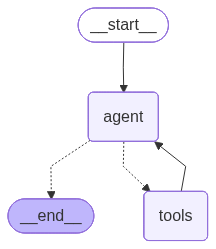

Graph visualization saved ✓


In [3]:
# Visualize the graph structure
try:
    from IPython.display import Image, display
    img = app.get_graph().draw_mermaid_png()
    with open('notebooks/agent_graph.png', 'wb') as f:
        f.write(img)
    display(Image(img))
    print('Graph visualization saved ✓')
except Exception as e:
    print(f'Graph image unavailable ({e})')
    print('\nGraph structure (text):')
    print(app.get_graph().draw_ascii())

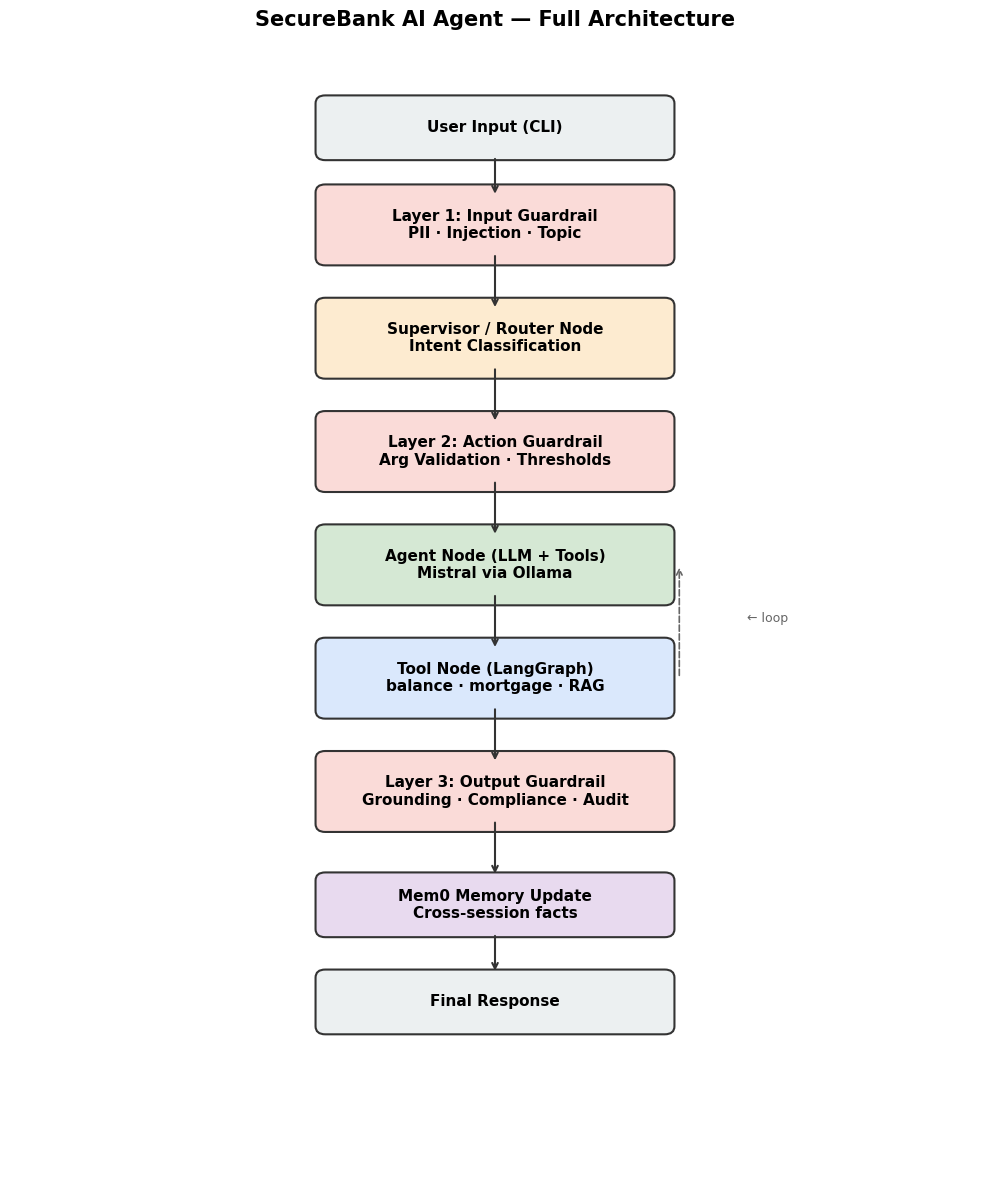

Architecture diagram saved ✓


In [4]:
# Architecture diagram using matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, color, fontsize=11):
    box = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.1', facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', wrap=True)

def arrow(ax, x, y1, y2):
    ax.annotate('', xy=(x, y2 + 0.35), xytext=(x, y1 - 0.35),
        arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

nodes = [
    (5, 13,   3.5, 0.6, 'User Input (CLI)',                '#ecf0f1'),
    (5, 11.8, 3.5, 0.8, 'Layer 1: Input Guardrail\nPII · Injection · Topic', '#fadbd8'),
    (5, 10.4, 3.5, 0.8, 'Supervisor / Router Node\nIntent Classification',   '#fdebd0'),
    (5,  9.0, 3.5, 0.8, 'Layer 2: Action Guardrail\nArg Validation · Thresholds', '#fadbd8'),
    (5,  7.6, 3.5, 0.8, 'Agent Node (LLM + Tools)\nMistral via Ollama',      '#d5e8d4'),
    (5,  6.2, 3.5, 0.8, 'Tool Node (LangGraph)\nbalance · mortgage · RAG',   '#dae8fc'),
    (5,  4.8, 3.5, 0.8, 'Layer 3: Output Guardrail\nGrounding · Compliance · Audit', '#fadbd8'),
    (5,  3.4, 3.5, 0.6, 'Mem0 Memory Update\nCross-session facts',            '#e8daef'),
    (5,  2.2, 3.5, 0.6, 'Final Response',                  '#ecf0f1'),
]

colors = [n[4] for n in nodes]
for x, y, w, h, text, color in nodes:
    draw_box(ax, x, y, w, h, text, color)

for i in range(len(nodes) - 1):
    arrow(ax, 5, nodes[i][1], nodes[i+1][1])

# Feedback loop arrow (tools → agent)
ax.annotate('', xy=(6.9, 7.6), xytext=(6.9, 6.2),
    arrowprops=dict(arrowstyle='->', color='#666', lw=1.2, linestyle='dashed'))
ax.text(7.6, 6.9, '← loop', fontsize=9, color='#666')

ax.set_title('SecureBank AI Agent — Full Architecture', fontsize=15,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('notebooks/agent_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Architecture diagram saved ✓')

In [5]:
# Trace a real query through the graph step by step
SYSTEM = """You are SecureBank's AI Financial Assistant.
Help customers with balances, mortgages, and policy questions.
Never recommend crypto or guarantee returns."""

query = 'What is the balance for CUST456?'
print(f'Query: "{query}"\n')
print('Streaming graph execution...')
print('─' * 60)

messages = [SystemMessage(content=SYSTEM), HumanMessage(content=query)]
for i, step in enumerate(app.stream({'messages': messages})):
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    last_msg = node_output['messages'][-1]
    print(f'Step {i+1} — Node: [{node_name}]')
    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
        for tc in last_msg.tool_calls:
            print(f'  → Tool call: {tc["name"]}({tc["args"]})')
    else:
        print(f'  → Content: {last_msg.content[:120]}')
    print()

Query: "What is the balance for CUST456?"

Streaming graph execution...
────────────────────────────────────────────────────────────


Step 1 — Node: [agent]
  → Content:  To find out the current account balance for customer CUST456, I will use the `get_account_balance` function:

```python



In [6]:
# Show available tools
print('Registered tools:')
print('─' * 50)
for t in all_tools:
    desc = t.description.split('\n')[0][:65]
    print(f'  {t.name:<35} {desc}')

Registered tools:
──────────────────────────────────────────────────
  get_account_balance                 Fetches the current account balance and account type for a given 
  simulate_mortgage                   Calculates the estimated monthly mortgage payment using standard 
  calculate_loan_affordability        Evaluates whether a customer qualifies for a SecureBank mortgage 
  check_overdraft_risk                Proactively checks if a planned purchase or transaction would put
  get_spending_summary                Returns a monthly spending breakdown by category for the given cu
  explain_decision                    Provides a plain-language explanation of an automated financial d
  search_bank_policies                Searches SecureBank's official internal policy documents using an
